In [1]:
import torch
import pandas as pd

from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

/root/miniforge3/envs/MIMICIV/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load and preprocess dataset
landmark_df = pd.read_csv('landmark_df.csv')  # Replace with your dataset

# Select patients with exactly 5 visits
visit_counts = landmark_df['subject_id'].value_counts()
patients_5_visits = visit_counts[visit_counts == 5].index
df_5_visits = landmark_df[landmark_df['subject_id'].isin(patients_5_visits)]

In [4]:
# Configuration
# TODO: place as well validation loss
MODEL_NAME = 'Charangan/MedBERT'  # MedBERT model
# TODO: Insert hyperparameter like in the lab settings
BATCH_SIZE = 16
EPOCHS = 3
MAX_LEN = 512

landmark_df = df_5_visits.copy()

# TODO: consider better
# Combine text columns
def combine_text(row):
    texts = []
    for col in ['med_text', 'diag_text', 'proc_text']:
        if pd.notna(row[col]):
            texts.append(row[col])
    return ' '.join(texts)

landmark_df['input_text'] = landmark_df.apply(combine_text, axis=1)

train_df, test_df = train_test_split(
    landmark_df[['input_text', 'death_in_90days']], 
    test_size=0.2, random_state=42, stratify=landmark_df['death_in_90days']
)

# Tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ClinicalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.encodings = tokenizer(texts.tolist(), truncation=True, padding=True, max_length=max_length)
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ClinicalDataset(train_df['input_text'], train_df['death_in_90days'], tokenizer, MAX_LEN)
test_dataset = ClinicalDataset(test_df['input_text'], test_df['death_in_90days'], tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Model setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

# Training loop
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        inputs = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**inputs)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch + 1}/{EPOCHS}, Training Loss: {avg_loss:.4f}')

# Evaluation
model.eval()
predictions, true_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        inputs = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
        predictions.extend(probs)
        true_labels.extend(batch['labels'].cpu().numpy())

auc_score = roc_auc_score(true_labels, predictions)
print(f'MedBERT AUC: {auc_score:.3f}')


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Charangan/MedBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/root/miniforge3/envs/MIMICIV/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/3, Training Loss: 0.4779
Epoch 2/3, Training Loss: 0.4017
Epoch 3/3, Training Loss: 0.2885
MedBERT AUC: 0.936


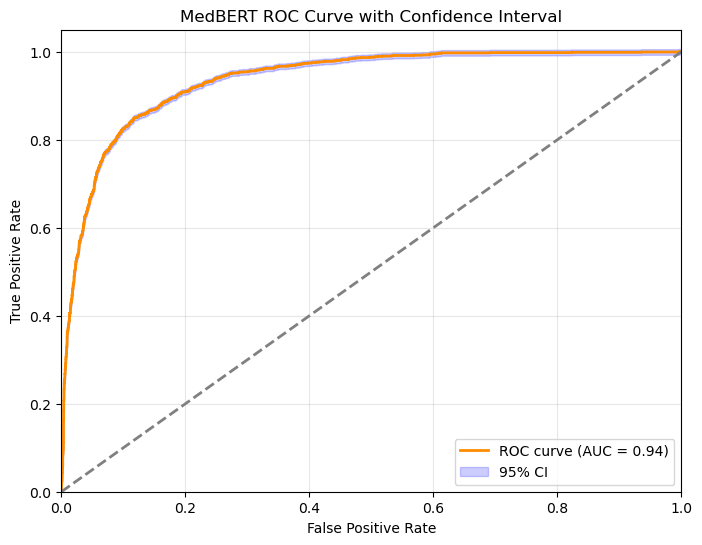

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from scipy import interp
from sklearn.utils import resample

# Assume true_labels and predictions obtained from MedBERT evaluation

# Function to calculate confidence intervals with bootstrap
def bootstrap_auc_ci(y_true, y_pred, n_bootstraps=1000, alpha=0.95):
    bootstrapped_scores = []
    rng = np.random.RandomState(42)
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = auc(*roc_curve(y_true[indices], y_pred[indices])[:2])
        bootstrapped_scores.append(score)

    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()
    lower = sorted_scores[int((1.0 - alpha) / 2 * len(sorted_scores))]
    upper = sorted_scores[int((alpha + (1.0 - alpha) / 2) * len(sorted_scores))]
    return lower, upper

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)
ci_lower, ci_upper = bootstrap_auc_ci(np.array(true_labels), np.array(predictions))

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr - (roc_auc - ci_lower), tpr + (ci_upper - roc_auc), alpha=0.2, color='blue', label=f'{95}% CI')

plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MedBERT ROC Curve with Confidence Interval')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

MODEL_NAME = 'Charangan/MedBERT'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Your existing landmark_df loaded
landmark_df = pd.read_csv('landmark_df.csv')

max_visits = 3  # Example for patients with exactly 5 visits
visit_counts = landmark_df['subject_id'].value_counts()
selected_patients = visit_counts[visit_counts == max_visits].index

df_selected = landmark_df[landmark_df['subject_id'].isin(selected_patients)].copy()

results = []
SEED = 42

def narrative_prompt(row):
    narrative = f"Patient is a {row['age_at_landmark']}-year-old {row['gender']}."
    narrative += f" This is the {row['num_total_visits']} visit."
    if row['days_since_previous_visit'] != -1:
        narrative += f" The last visit happened {row['days_since_previous_visit']} days ago."

    if pd.notna(row['diag_text']) and row['diag_text'].strip():
        narrative += f" Medical history includes: {row['diag_text']}."

    if pd.notna(row['med_text']) and row['med_text'].strip():
        narrative += f" Current medications are: {row['med_text']}."

    if pd.notna(row['proc_text']) and row['proc_text'].strip():
        narrative += f" Procedures performed: {row['proc_text']}."

    return narrative

/root/miniforge3/envs/MIMICIV/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
landmark_visit = 1
df_subset = df_selected[df_selected['landmark_visit'] == landmark_visit]
df_subset

,subject_id,landmark_visit,age_at_landmark,gender,num_total_visits,death_in_90days,med_text,diag_text,proc_text,gender_numeric,days_since_previous_visit
22,10000826,1,32,F,1,0,Morphine Sulfate Lorazepam Heparin Docusate So...,"Alcoholic cirrhosis of liver Pneumonia, organi...",Percutaneous abdominal drainage,0,-1.0
44,10001186,1,46,F,1,0,Sodium Chloride 0.9% Flush Ondansetron Guaife...,Disruption of external operation (surgical) wo...,Removal of skull plate,0,-1.0
49,10001319,1,29,F,1,0,Ibuprofen Oxycodone-Acetaminophen Bisacodyl Di...,"First-degree perineal laceration, delivered, w...",Repair of other current obstetric laceration,0,-1.0
118,10002131,1,87,F,1,1,Aspirin D5 1/2NS Heparin Latanoprost 0.005% Op...,"Acute kidney failure, unspecified Enteritis du...",Unknown,0,-1.0
152,10002528,1,26,F,1,0,Potassium Chloride Cyanocobalamin 0.9% Sodium ...,Other dissociative and conversion disorders Ot...,Unknown,0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...
545867,19997538,1,53,M,1,0,GlipiZIDE Insulin Heparin Phenazopyridine HYDR...,Malignant neoplasm of rectum Secondary maligna...,"Resection of Rectum, Percutaneous Endoscopic A...",1,-1.0
545905,19997887,1,59,F,1,0,Unknown,"Chest pain, unspecified",Unknown,0,-1.0
545943,19998562,1,79,M,1,0,0.9% Sodium Chloride Calcium Gluconate Potassi...,"Anemia, unspecified Thrombocytopenia, unspecif...",Unknown,1,-1.0
545963,19999043,1,35,F,1,0,OxyCODONE (Immediate Release) Ferrous Sulfate ...,(Induced) termination of pregnancy with other ...,"Abortion of Products of Conception, Vacuum, Vi...",0,-1.0


In [2]:
class ClinicalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Store predictions and labels for confidence intervals
predictions_list = []
labels_list = []

for landmark_visit in range(1, max_visits + 1):
    print(f"Fine-tuning and evaluating at Landmark {landmark_visit}")

    df_subset = df_selected[df_selected['landmark_visit'] == landmark_visit]

    patients = df_subset['subject_id'].unique()

    train_patients, test_patients = train_test_split(
        patients,
        test_size=0.2,
        random_state=SEED,
        stratify=df_subset.groupby('subject_id')['death_in_90days'].max()
    )

    train_df = df_subset[df_subset['subject_id'].isin(train_patients)].copy()
    test_df = df_subset[df_subset['subject_id'].isin(test_patients)].copy()
    
    # Clearly apply the narrative_prompt function
    train_texts = train_df.apply(narrative_prompt, axis=1).tolist()
    train_labels = train_df['death_in_90days'].tolist()

    test_texts = test_df.apply(narrative_prompt, axis=1).tolist()
    test_labels = test_df['death_in_90days'].tolist()

    # train_texts = train_df.apply(lambda row: ' '.join(filter(None, [row['med_text'], row['diag_text'], row['proc_text']])), axis=1).tolist()
    # train_labels = train_df['death_in_90days'].tolist()

    # test_texts = test_df.apply(lambda row: ' '.join(filter(None, [row['med_text'], row['diag_text'], row['proc_text']])), axis=1).tolist()
    # test_labels = test_df['death_in_90days'].tolist()

    train_dataset = ClinicalDataset(train_texts, train_labels, tokenizer)
    test_dataset = ClinicalDataset(test_texts, test_labels, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

    optimizer = AdamW(model.parameters(), lr=2e-5)
    
    # model.train()
    # for epoch in range(epochs):
    #     total_loss = 0
    #     for batch in train_loader:
    #         optimizer.zero_grad()
    #         inputs = {k: v.to(device) for k, v in batch.items()}
    #         outputs = model(**inputs)
    #         loss = outputs.loss
    #         loss.backward()
    #         optimizer.step()
    #         total_loss += loss.item()
    #     avg_loss = total_loss / len(train_loader)
    #     print(f'Landmark {landmark_visit}, Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

    epochs = 5  # Allow more epochs
    patience = 1  # Stop if no improvement after 3 epochs
    best_val_auc = 0.0
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        # Training phase
        for batch in train_loader:
            optimizer.zero_grad()
            inputs = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**inputs)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Validation phase
        model.eval()
        val_predictions, val_labels = [], []

        with torch.no_grad():
            total_val_loss = 0
            for batch in test_loader:
                inputs = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**inputs)
                val_loss = outputs.loss
                total_val_loss += val_loss.item()
                
                probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
                val_predictions.extend(probs)
                val_labels.extend(batch['labels'].cpu().numpy())

        avg_val_loss = total_val_loss / len(test_loader)
        val_auc = roc_auc_score(val_labels, val_predictions)

        print(f'Epoch {epoch+1}/{epochs} | '
            f'Train Loss: {avg_train_loss:.4f} | '
            f'Validation Loss: {avg_val_loss:.4f} | '
            f'Validation AUC: {val_auc:.4f}')

        # Check early stopping conditions
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            epochs_no_improve = 0
            # Optionally save best model weights:
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after epoch {epoch+1}')
                break

    # Load best model after early stopping:
    model.load_state_dict(torch.load('best_model.pt'))
    
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            inputs = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
            predictions.extend(probs)
            true_labels.extend(batch['labels'].cpu().numpy())

    auc = roc_auc_score(true_labels, predictions)
    mortality_rate = np.mean(test_labels) * 100
    num_patients = len(test_df)

    results.append({
        'Landmark (Visit Number)': landmark_visit,
        'Number of Patients (Test)': num_patients,
        'Mortality (%)': f"{mortality_rate:.1f}%",
        'AUC MedBERT': f"{auc:.4f}"
    })

    predictions_list.append(predictions)
    labels_list.append(true_labels)

# Confidence interval calculation
def bootstrap_auc_ci(y_true, y_pred, n_bootstraps=1000, alpha=0.95):
    bootstrapped_scores = []
    rng = np.random.RandomState(SEED)
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        if len(np.unique(np.array(y_true)[indices])) < 2:
            continue
        score = roc_auc_score(np.array(y_true)[indices], np.array(y_pred)[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()
    lower = sorted_scores[int((1.0 - alpha) / 2 * len(sorted_scores))]
    upper = sorted_scores[int((alpha + (1.0 - alpha) / 2) * len(sorted_scores))]
    return lower, upper

landmark_visits = list(range(1, max_visits + 1))
auc_means = []
ci_lowers = []
ci_uppers = []

for preds, labels in zip(predictions_list, labels_list):
    auc = roc_auc_score(labels, preds)
    ci_lower, ci_upper = bootstrap_auc_ci(labels, preds)
    auc_means.append(auc)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)

# Plot AUC with CI
plt.figure(figsize=(10, 6))
plt.plot(landmark_visits, auc_means, marker='o', color='steelblue', label='Mean AUC')
plt.fill_between(landmark_visits, ci_lowers, ci_uppers, color='steelblue', alpha=0.2, label='95% CI')
plt.xticks(landmark_visits)
plt.xlabel('Landmark Visit')
plt.ylabel('AUC')
plt.title('MedBERT Predictive Performance by Landmark Visit')
plt.legend()
plt.grid(alpha=0.4)
plt.ylim([0.5, 1.0])
plt.show()

results_df = pd.DataFrame(results)
print(results_df)


Fine-tuning and evaluating at Landmark 1


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Charangan/MedBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/root/miniforge3/envs/MIMICIV/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/5 | Train Loss: 0.3512 | Validation Loss: 0.3329 | Validation AUC: 0.8197


KeyboardInterrupt: 